<a href="https://colab.research.google.com/github/RichaGaharwar/Exploratory-Data-Analysis-Netflix-/blob/main/Netflix_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---


**About NETFLIX**


---



Netflix is one of the most popular media and video streaming platforms. They have over 10000 movies or tv shows available on their platform, as of mid-2021, they have over 222M Subscribers globally. This tabular dataset consists of listings of all the movies and tv shows available on Netflix, along with details such as - cast, directors, ratings, release year, duration, etc.


---



**Business Problem**


---



Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries



---




**Dataset**

---

The dataset provided to you consists of a list of all the TV shows/movies available on Netflix:

---

*   Show_id: Unique ID for every Movie / Tv Show
*   Type: Identifier - A Movie or TV Show
*   Title: Title of the Movie / Tv Show
*   Director: Director of the Movie
*   Cast: Actors involved in the movie/show
*   Country: Country where the movie/show was produced
*   Date_added: Date it was added on Netflix
*   Release_year: Actual Release year of the movie/show
*   Rating: TV Rating of the movie/show
*   Duration: Total Duration - in minutes or number of seasons
*   Listed_in: Genre
*   Description: The summary description

---

**Hints**

---

1. The exploration should have a goal. As you explore the data, keep in mind
that you want to answer which type of shows to produce and how to grow the business.

2. Ensure each recommendation is backed by data. The company is looking for data-driven insights, not personal opinions or anecdotes.

3. Assume that you are presenting your findings to business executives who have only a basic understanding of data science. Avoid unnecessary technical jargon.

4. Start by exploring a few questions:

* What type of content is available in different countries?
* How has the number of movies released per year changed over the last 20-30 years?
* Comparison of tv shows vs. movies.
* What is the best time to launch a TV show?
* Analysis of actors/directors of different types of shows/movies.
* Does Netflix has more focus on TV Shows than movies in recent years
* Understanding what content is available in different countries

---


**Evaluation Criteria**

---


1. Defining Problem Statement and Analysing basic metrics

2. Observations on the shape of data, data types of all the attributes, conversion of categorical attributes to 'category'
(If required), missing value detection, statistical summary

3. Non-Graphical Analysis: Value counts and unique attributes

4. Visual Analysis - Univariate, Bivariate after pre-processing of the data

Note: Pre-processing involves unnesting of the data in columns like Actor, Director, Country

* For continuous variable(s): Distplot, countplot, histogram for univariate analysis

* For categorical variable(s): Boxplot

5. Missing Value & Outlier check (Treatment optional)

6. Insights based on Non-Graphical and Visual Analysis

* Comments on the range of attributes

* Comments on the distribution of the variables and relationship between them

* Comments for each univariate and bivariate plot

7. Business Insights - Should include patterns observed in the data along with what you can infer from it

8. Recommendations - Actionable items for business. No technical jargon. No complications.

---



Importing necessary libraries and dataset first

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

netflix = pd.read_csv('/content/netflix_titles.csv')
netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **Data Cleaning:**





In [34]:
netflix2 = netflix.copy()

In [35]:
netflix['director'].value_counts().tail(8)

,count
director,
Christian De Vita,1
Kirati Nakintanon,1
Mark Risley,1
James Brown,1
Ivona Juka,1
Mu Chu,1
Chandra Prakash Dwivedi,1
Majid Al Ansari,1


In [36]:
netflix2 = netflix2.assign(director = netflix2['director'].str.split(',')).explode('director')
netflix2['director'] = netflix2['director'].str.strip()
print(f"Unique directors: {netflix2['director'].nunique()}")

Unique directors: 4993


In [37]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9612 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9612 non-null   object
 1   type          9612 non-null   object
 2   title         9612 non-null   object
 3   director      6978 non-null   object
 4   cast          8652 non-null   object
 5   country       8731 non-null   object
 6   date_added    9602 non-null   object
 7   release_year  9612 non-null   int64 
 8   rating        9608 non-null   object
 9   duration      9609 non-null   object
 10  listed_in     9612 non-null   object
 11  description   9612 non-null   object
dtypes: int64(1), object(11)
memory usage: 976.2+ KB


In [38]:
netflix['country'].value_counts().tail(10)

,count
country,
"India, United Kingdom, Canada, United States",1
"Philippines, United States",1
"Romania, Bulgaria, Hungary",1
"Uruguay, Guatemala",1
"France, Senegal, Belgium",1
"Mexico, United States, Spain, Colombia",1
"Canada, Norway",1
"Finland, Germany, Belgium",1
"Argentina, United States, Mexico",1


*   multiple country name in 1 row
*   country column needs unnesting




In [39]:
netflix['country'].nunique()

748

In [40]:
netflix2 = netflix2.assign(country = netflix2['country'].str.split(',')).explode('country')
netflix2['country'] = netflix2['country'].str.strip()
print(f"Unique countries: {netflix2['country'].nunique()}")

Unique countries: 123


In [41]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11917 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       11917 non-null  object
 1   type          11917 non-null  object
 2   title         11917 non-null  object
 3   director      8947 non-null   object
 4   cast          10725 non-null  object
 5   country       11036 non-null  object
 6   date_added    11907 non-null  object
 7   release_year  11917 non-null  int64 
 8   rating        11913 non-null  object
 9   duration      11914 non-null  object
 10  listed_in     11917 non-null  object
 11  description   11917 non-null  object
dtypes: int64(1), object(11)
memory usage: 1.2+ MB


In [42]:
netflix2.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [43]:
netflix['cast'].value_counts().tail(10)

,count
cast,
"Chutimon Chuengcharoensukying, Sutthirak Subvijitra, Nutthasit Kotimanuswanich, Sita Maharavidejakorn, Sutthatip Wutichaipradit, Warisara Yu, Chokchai Charoensuk, Supoj Pongpancharoen, Nikorn Sae Tang, Gandhi Wasuwitchayagit, Petchpatchara Kitkrairaj, Duangjai Hirunsri, Nilacha Fuangfukiet, Teeranai Na Nongk้hai, Sumontha Suanpolrat, Wimolphan Chaleejunghan, Damkerng Thitapiyasak, Natthawara Hongsuwan, Nunthapak Chalermpuwadej, Tachatorn Supanan",1
Roberto Palazuelos,1
"Michael Peña, Diego Luna, Tenoch Huerta, Joaquin Cosio, José María Yazpik, Matt Letscher, Alyssa Diaz",1
"Nick Lachey, Vanessa Lachey",1
"Takeru Sato, Kasumi Arimura, Haru, Kentaro Sakaguchi, Takayuki Yamada, Kendo Kobayashi, Ken Yasuda, Arata Furuta, Suzuki Matsuo, Koichi Yamadera, Arata Iura, Chikako Kaku, Kotaro Yoshida",1
"Toyin Abraham, Sambasa Nzeribe, Chioma Chukwuka Akpotha, Chioma Omeruah, Chiwetalu Agu, Dele Odule, Femi Adebayo, Bayray McNwizu, Biodun Stephen",1
"Neeraj Kabi, Geetanjali Kulkarni, Danish Husain, Sheeba Chaddha, Paras Priyadarshan, Anshul Chauhan, Anud Singh Dhaka, Shirin Sewani, Mihir Ahuja, Vasundhara Rajput",1
"Sanjay Dutt, Arjun Kapoor, Kriti Sanon, Zeenat Aman, Mohnish Bahl, Padmini Kolhapure, Kunal Kapoor, Suhasini Mulay",1
"Lika Berning, Bobby van Jaarsveld, Marlee van der Merwe, Sonja Herholdt, Elize Cawood, Rouel Beukes, Kevin Leo, Paul du Toit, Sylvaine Strike",1


In [44]:
netflix2 = netflix2.assign(cast = netflix2['cast'].str.split(',')).explode('cast')
netflix2['cast'] = netflix2['cast'].str.strip()
print(f"Unique casts: {netflix2['cast'].nunique()}")

Unique casts: 36439


In [45]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89415 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       89415 non-null  object
 1   type          89415 non-null  object
 2   title         89415 non-null  object
 3   director      67478 non-null  object
 4   cast          88223 non-null  object
 5   country       83994 non-null  object
 6   date_added    89346 non-null  object
 7   release_year  89415 non-null  int64 
 8   rating        89377 non-null  object
 9   duration      89412 non-null  object
 10  listed_in     89415 non-null  object
 11  description   89415 non-null  object
dtypes: int64(1), object(11)
memory usage: 8.9+ MB


In [46]:
netflix2.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


# Exploratory Data Analysis

Let's know what kind of information & how much of data we have:

In [47]:
netflix2.shape

(89415, 12)

In [48]:
netflix2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89415 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       89415 non-null  object
 1   type          89415 non-null  object
 2   title         89415 non-null  object
 3   director      67478 non-null  object
 4   cast          88223 non-null  object
 5   country       83994 non-null  object
 6   date_added    89346 non-null  object
 7   release_year  89415 non-null  int64 
 8   rating        89377 non-null  object
 9   duration      89412 non-null  object
 10  listed_in     89415 non-null  object
 11  description   89415 non-null  object
dtypes: int64(1), object(11)
memory usage: 8.9+ MB


we have 12 different features:


---


**Columns and Data Types:**

---
*   Most (11/12) columns are of object dtype, which typically means that we are dealing with Categorical data ie., to generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries we need to find how each of the features are  corelated to each other.
---
 **Non-Null Counts (Missing Values):**

---

*   Director: 2634 missing values.
*   Country: 831 missing values.
*   cast: 825 missing values.
*   date_added: 10 missing values.
*   rating: 4 missing values.
*   duration: 3 missing values.
---
**Key Takeaways:**

---
*   The dataset is relatively clean, there are still missing values in director, country cast, date_added, rating, and duration columns that might need further attention depending on the analysis.

*   The date_added column is in a numerical format, which needs to be converted into datetime format

` 825 missing values in the 'cast' column, 2634 missing values in 'director' column, 831 missing values in 'country' column are crucial for a recommendation system. Here's why:`

**Impact on Feature Engineering:**

In a recommendation system, information like 'cast', 'director', 'country' are often used as a feature to help the system understand the content.

For example:
if a user likes movie with a particular actor, the system can recommend other movies starring that actor.

**Reduced Recommendation Quality:**

A recommendation model trained on data with significant missing values will likely provide less accurate or less personalized recommendations for the affected titles.

It won't be able to leverage the information to find similarities or user preferences related to actors, directors or country.

**Bias in Recommendations:**

If the missing values are not random, the recommendation system might develop a bias, under-representing or mis-recommending those titles.

**Data Imputation Challenges:**

While one could try to impute (fill in) these missing values, accurately predicting the cast, director or country of a movie or TV show without any initial information is very difficult and could introduce noise or incorrect information into the dataset.


---


In essence, for a recommendation system that relies on content features, 825 missing 'cast',  2634 missing 'director' or 831 missing 'country' entries represent a significant loss of valuable information that can directly hinder the system's ability to learn and suggest relevant content.

## **Handling Missing Values**

To ensure data completeness and avoid issues in further analysis, I'll fill the missing values in the 'director', 'cast' and 'country' columns with 'Unknown'.

In [49]:
netflix2['director'].fillna('unknown', inplace=True)
netflix2['country'].fillna('unknown', inplace=True)
netflix2['cast'].fillna('unknown', inplace=True)
netflix2['duration'].fillna('unknown', inplace=True)
netflix2['rating'].fillna('unknown', inplace=True)

/tmp/ipykernel_530/1780645150.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  netflix2['director'].fillna('unknown', inplace=True)
/tmp/ipykernel_530/1780645150.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

we have filled all the missing values with unknown except 'date_added'

In [50]:
netflix2['type'].value_counts()

,count
type,
Movie,65379
TV Show,24036


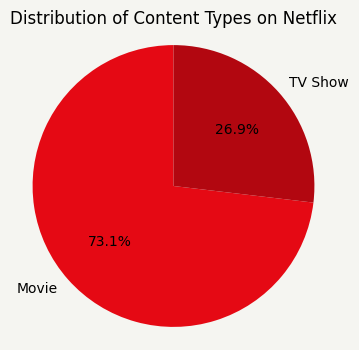

In [51]:
content_type_counts = netflix2['type'].value_counts()
plt.figure(figsize = (4,4), facecolor='#f5f5f1')
plt.pie(content_type_counts, labels = content_type_counts.index, autopct= "%1.1f%%", startangle = 90, colors = ['#E50914', '#B20710'])
plt.title("Distribution of Content Types on Netflix")
plt.axis("equal")
plt.show()

From the output, we can see that out of 8807 records the dataset contains:

 **6131 Movies &
2676 TV Shows**

In [52]:
netflix2['director'].value_counts()

,count
director,
unknown,21937
Martin Scorsese,217
Steven Spielberg,205
Martin Campbell,154
Raja Gosnell,154
...,...
Anatole Litvak,1
Alicky Sussman,1
Milla Harrison-Hansley,1





*   Rajiv Chilaka is the most frequent director, with 19 titles.
*   Raúl Campos, Jan Suter come in second with 18 titles.
*   The list shows a long tail, indicating that many directors have only a few titles on Netflix, while a small number of directors are very prolific.
*   There are a total of 4528 unique directors listed in the dataset. This implies a very diverse range of creators on the platform.





In [68]:
# Get the top 10 countries by content count
top_10_countries = netflix2['country'].value_counts().head(20)
display(top_10_countries)

,count
country,
United States,30472
India,8537
United Kingdom,5723
unknown,5421
Canada,3946
Japan,3758
France,3489
Spain,2033
Germany,1927


/tmp/ipykernel_530/26713242.py:8: UserWarning: 
The palette list has fewer values (10) than needed (20) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


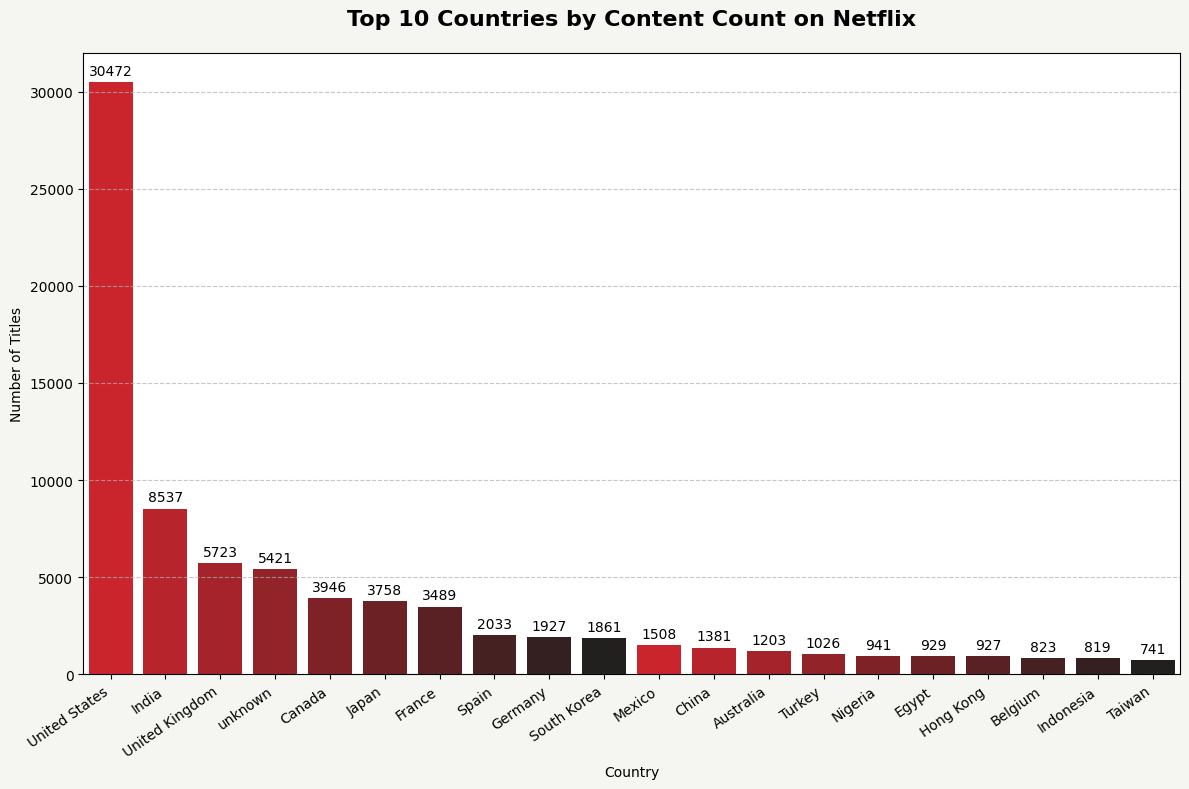

In [69]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = top_10_countries.index,
    y = top_10_countries.values,
    palette= custom_palette,
    hue = top_10_countries.index,
    legend=False
)

plt.title('Top 10 Countries by Content Count on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The output shows the top 10 countries by content count on Netflix:


*   **United States** leads significantly with **2818 titles**.
*   **India** is second with **972 titles**.
*   The **'Unknown'** category, which was used to fill missing values, accounts for **831 titles**, indicating a substantial number of entries where the country of origin was not specified.
*   The **United Kingdom** follows with **419 titles**.
*   Other countries in the **top 10 include Japan, South Korea, Canada, Spain, France,** and **Mexico**.










In [55]:
netflix2['release_year'].nunique()

74

74 years of data

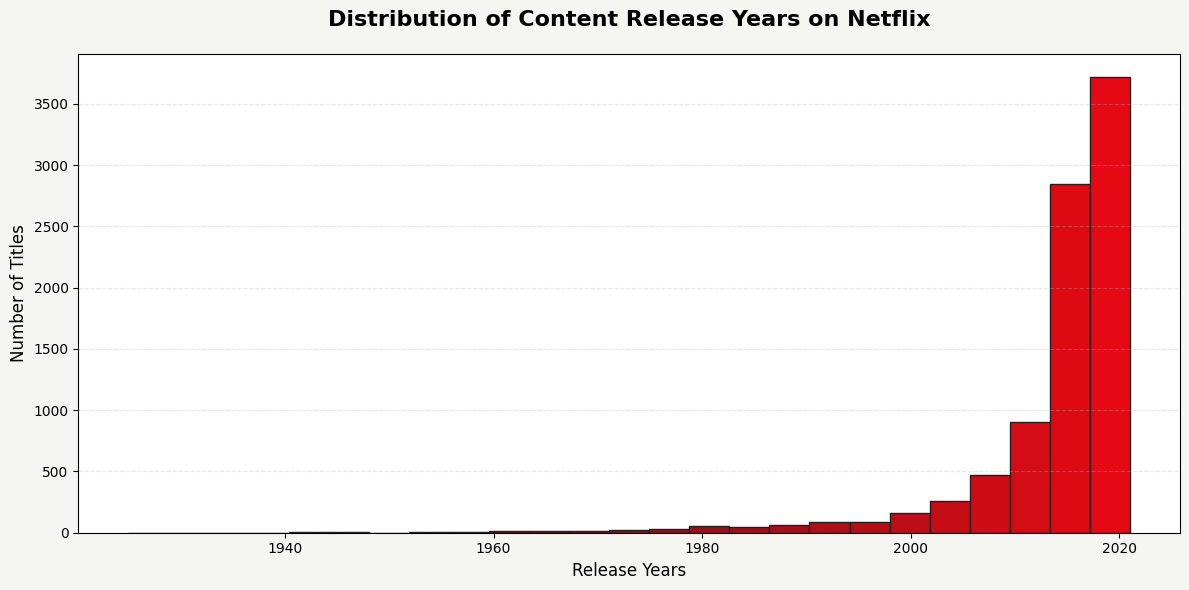

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

netflix_red = '#E50914'
netflix_dark = '#221F1F'
cmap_colors = [netflix_dark, netflix_red]
n_bin = 25
netflix_cmap = LinearSegmentedColormap.from_list("netflix_red_fade", cmap_colors, N=n_bin)

plt.figure(figsize=(12, 6), facecolor='#f5f5f1')

ax = sns.histplot(netflix['release_year'], bins=n_bin, color=netflix_red, edgecolor=netflix_dark)
patches = ax.patches

N_bars = len(patches)
norm = mcolors.Normalize(0, N_bars - 1)

for i, patch in enumerate(patches):
    color = netflix_cmap(norm(i))
    patch.set_facecolor(color)

# 5. Styling
plt.title('Distribution of Content Release Years on Netflix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Release Years', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Insights from `release_year`:

*   Netflix has a significant amount of newer content, with the years 2018, 2017, and 2019 being the most prolific. This suggests a focus on recent productions.
*   While there's a strong presence of recent releases, the dataset also includes older titles, with some dating back to 1925 and 1947, indicating a diverse library that spans many decades.
*   The peak in content production seems to be around 2018-2019, potentially reflecting a period of aggressive content acquisition or production by Netflix.

In [57]:
netflix2['rating'].value_counts()

,count
rating,
TV-MA,29880
TV-14,17450
R,12865
PG-13,7814
TV-PG,6356
PG,5182
TV-Y7,4073
TV-Y,2745
TV-G,1329


### Insights from `rating`:

*   **Dominant Ratings:** The most common ratings are `TV-MA` (3207 titles), `TV-14` (2160 titles), and `TV-PG` (863 titles), indicating a significant amount of content aimed at mature or teenage audiences.
*   **Movie Ratings:** Ratings like `R`, `PG-13`, `PG`, `G`, and `NC-17` are also present, reflecting the diverse movie library.
*   **TV Show Ratings:** Ratings like `TV-Y7`, `TV-Y`, `TV-G`, and `TV-Y7-FV` are specific to TV shows and indicate content suitable for younger viewers.
*   **Anomalies:** There are a few entries like '74 min', '84 min', and '66 min' which appear to be durations rather than ratings. These are likely data entry errors and would need to be cleaned if a detailed analysis of ratings is required.

In [58]:
netflix2.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,unknown,Ama Qamata,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,unknown,Khosi Ngema,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,unknown,Gail Mabalane,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,unknown,Thabang Molaba,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


In [59]:
movie_ratings = netflix2[netflix2['type']=='Movie']['rating'].value_counts()

# **Type & Rating of content**

/tmp/ipykernel_530/2506441155.py:8: UserWarning: 
The palette list has fewer values (10) than needed (18) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


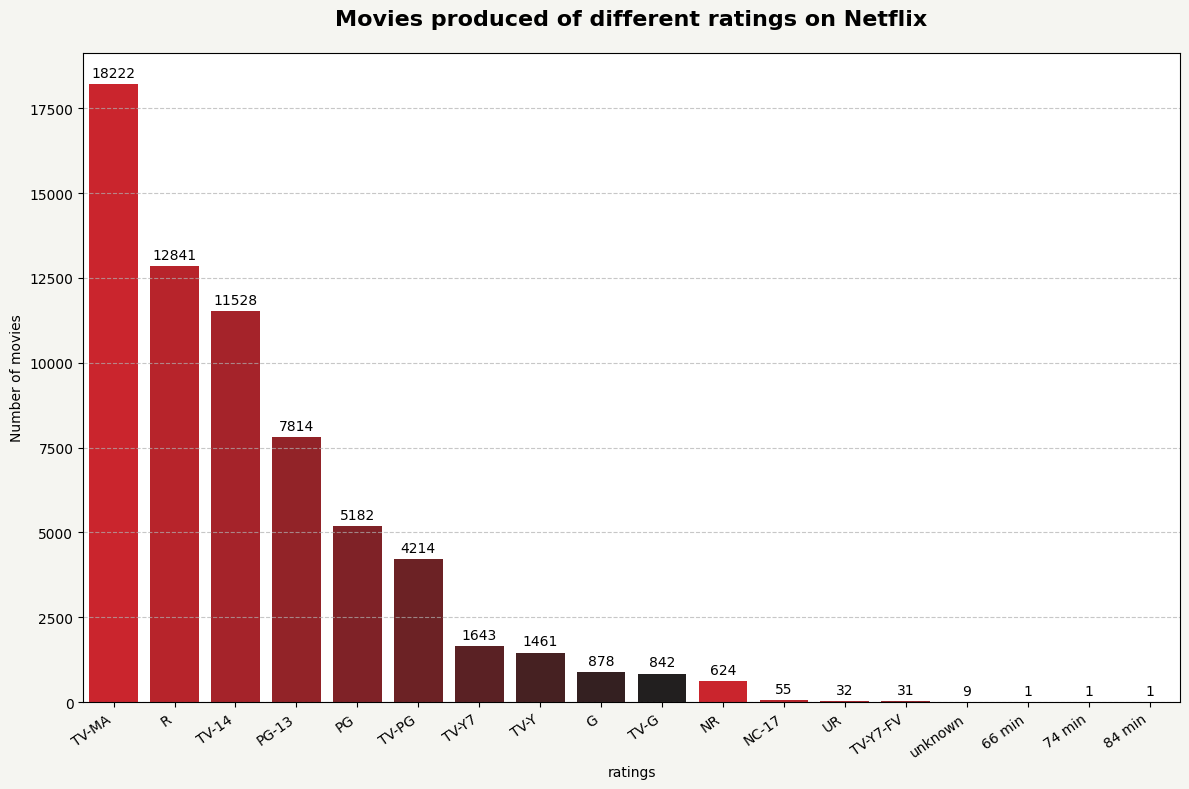

In [60]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = movie_ratings.index,
    y = movie_ratings.values,
    palette= custom_palette,
    hue = movie_ratings.index,
    legend=False
)

plt.title('Movies produced of different ratings on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('ratings')
plt.ylabel('Number of movies')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [61]:
TVShow_ratings = netflix2[netflix2['type']=='TV Show']['rating'].value_counts()

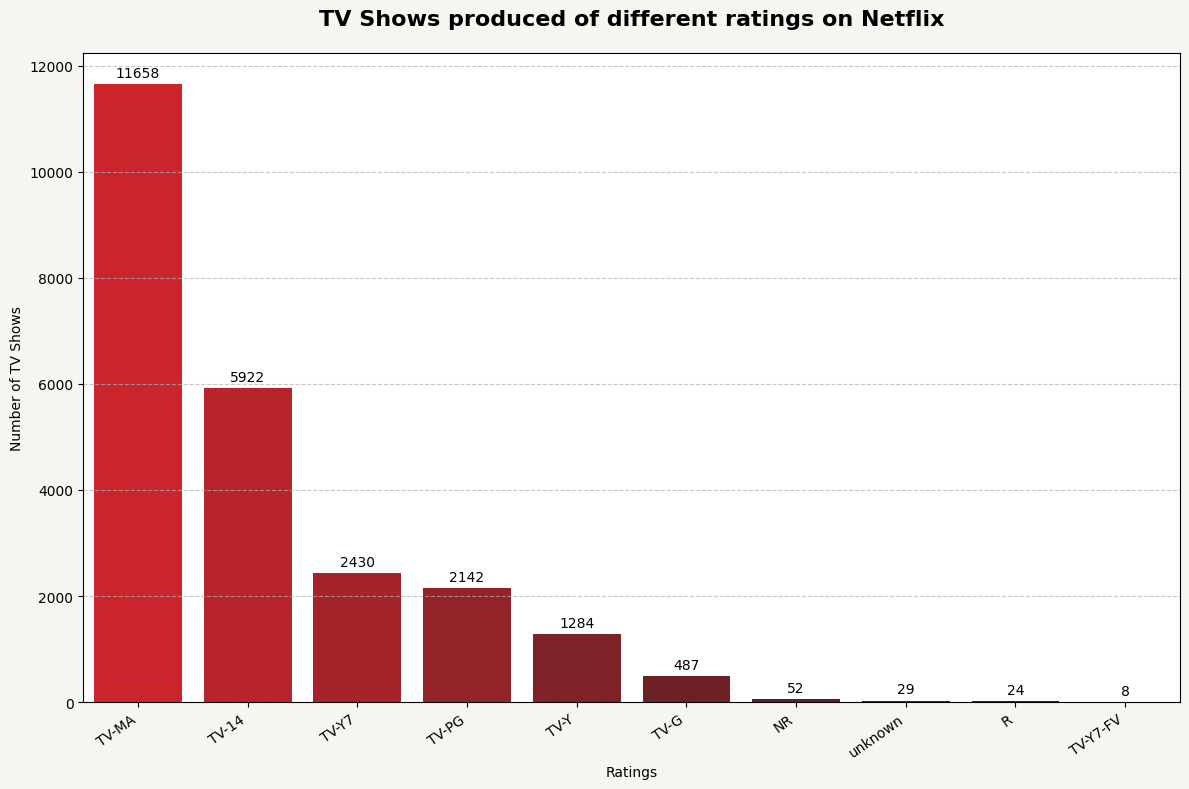

In [62]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = TVShow_ratings.index,
    y = TVShow_ratings.values,
    palette= custom_palette,
    hue = TVShow_ratings.index,
    legend=False
)

plt.title('TV Shows produced of different ratings on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ratings')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [63]:
netflix2['duration'].value_counts()

,count
duration,
1 Season,14624
2 Seasons,4222
3 Seasons,2230
94 min,2193
106 min,1875
...,...
11 min,2
196 min,2
18 min,2


# **Analysis on duration**

In [64]:
movies = netflix2[netflix2['type']=='Movie'].copy()
movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_530/3968725685.py:2: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_num'] = movies['duration'].str.extract('(\d+)').astype(float)


NameError: name 'mean' is not defined

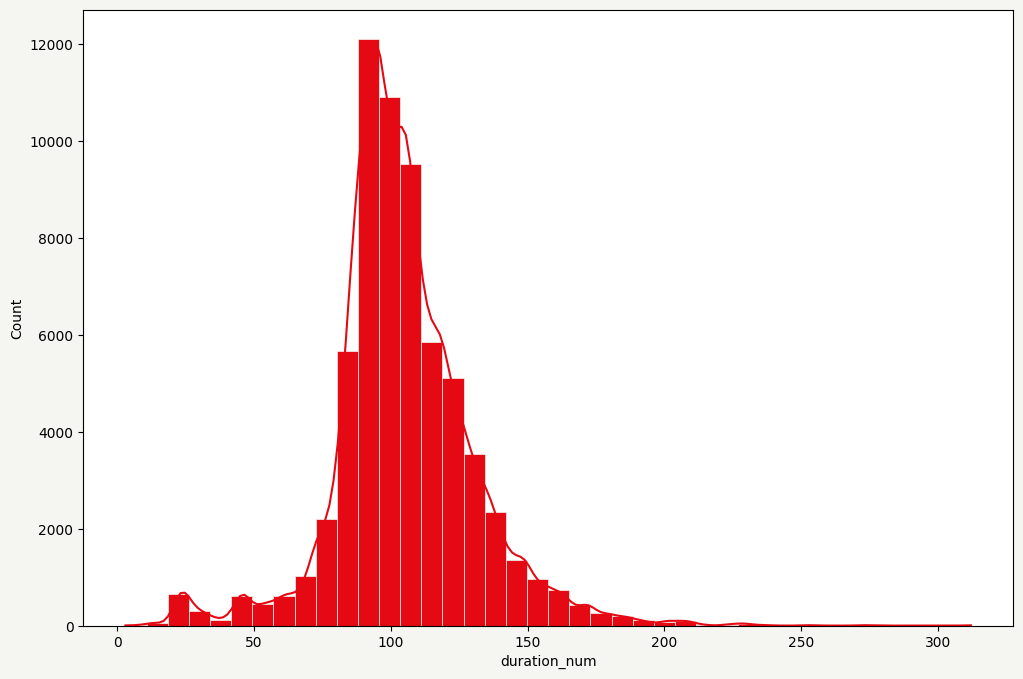

In [65]:
Netflix_Red = '#E50914'
white = '#F5F5F1'
Netflix_Black = '#221F1F'
plt.figure(figsize=(12,8), facecolor='#f5f5f1')
sns.histplot(movies['duration_num'], bins = 40, kde = True , color = Netflix_Red, alpha = 1, edgecolor = white, linewidth = 0.5)
plt.axvline(mean, color = 'black', linestyle = '--', linewidth=2, label = 'Mean')


plt.title('Distribution of Movie Durations on Netflix (with 95% C.I.)')
plt.xlabel('Duration (in minutes)')
plt.ylabel('count')
plt.legend()
plt.grid(axis = 'y', linestyle = '--', alpha=0.5)
plt.show()

The movie library on Netflix is heavily standardized, with a clear preference for content in the 90–110 minute range. While the platform supports a wide variety of lengths, the distribution follows a near-normal curve, suggesting that streaming consumption habits still align closely with traditional cinema timing.

In [ ]:
TV_shows = netflix2[netflix2['type']=='TV Show'].copy()
TVShow_durations = TV_shows['duration'].value_counts()
TVShow_durations

In [ ]:
netflix_red = '#E50914'
netflix_dark = '#221F1F'

custom_palette = sns.blend_palette([netflix_dark, netflix_red], n_colors=10)
custom_palette = list(reversed(custom_palette))

plt.figure(figsize=(12, 8), facecolor='#f5f5f1')
ax = sns.barplot(
    x = TVShow_durations.index,
    y = TVShow_durations.values,
    palette= custom_palette,
    hue = TVShow_durations.index,
    legend=False
)

plt.title('TV Shows produced of different durations on Netflix',fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Durations')
plt.ylabel('Number of TV Shows')
plt.xticks(rotation=35, ha='right')

for i in ax.containers:
  ax.bar_label(i, padding = 3)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
recent_movie = movies[movies['release_year']>=2010]
yearly_avg = recent_movie.groupby('release_year')['duration_num'].mean()

plt.figure(figsize=(12,8), facecolor='#f5f5f1')
sns.lineplot(x = yearly_avg.index, y = yearly_avg.values, marker='o' , color = 'red')
plt.title('Average Movie Duration Over Time')
plt.xlabel('Release Year')
plt.ylabel('Average Duration (in minutes)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Regarding release_year, the key insights are:

Netflix shows a strong focus on recent productions, with the years 2018, 2017, and 2019 having the most prolific content releases.
The platform has a diverse library that also includes older titles, some dating back to 1925 and 1947.
There was a peak in content production around 2018-2019, which could indicate a period of aggressive content acquisition or production by Netflix.

In [ ]:
netflix2[netflix2['type']=='Movie']['listed_in'].value_counts()

In [ ]:
netflix2[netflix2['type']=='TV Show']['listed_in'].value_counts()